# 3. Auditoría de fuga de datos y preprocesamiento

Este capítulo cubre la sección 2.5, auditoría de fuga de datos, y la sección 2.9,
preprocesamiento, de la guía. Igual que en el EDA, todo se calcula solo con el conjunto de
entrenamiento.


In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import *

estilo_graficos()
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

train, test = cargar_particiones()
y = train[OBJETIVO]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

## 2.5 Auditoría de fuga de datos (data leakage)

### 2.5.1 Disponibilidad de cada variable en el momento de la predicción

El escenario de uso es un adulto del que se conoce su perfil de factores de riesgo, datos que
podrían estar en una historia clínica o un formulario de ingreso, y del que todavía no se sabe si
tiene dificultad cognitiva. Una variable es legítima solo si estaría disponible en ese momento, sin
conocer todavía la respuesta.


In [2]:
auditoria = pd.DataFrame([
    ("edad, sexo, raza_etnia", "Sí", "Datos sociodemográficos básicos, conocidos antes de cualquier evaluación.", "Usar"),
    ("educacion", "Sí", "Dato sociodemográfico estable; se registra en la historia clínica.", "Usar"),
    ("hipertension, colesterol_alto, diabetes, acv", "Sí",
     "Diagnósticos previos ('alguna vez le dijeron...'); anteceden a la pregunta de cognición.", "Usar"),
    ("depresion_dx", "Sí", "Diagnóstico previo registrable en la historia clínica.", "Usar"),
    ("frecuencia_depresion", "Sí",
     "Síntoma afectivo medido con una pregunta distinta; no menciona memoria ni concentración.", "Usar (en observación)"),
    ("dificultad_auditiva, dificultad_visual", "Sí",
     "Funcionamiento sensorial, medible con tamizajes auditivos/visuales independientes.", "Usar (en observación)"),
    ("tabaquismo, imc_categoria", "Sí", "Hábitos y antropometría de rutina.", "Usar"),
    ("frecuencia_dificultad_cog", "No",
     "Pregunta de seguimiento que solo existe si la respuesta al objetivo fue 'sí': contiene el objetivo.", "Descartar"),
    ("discapacidad", "No",
     "Indicador construido por el NCHS a partir de 6 preguntas, una de ellas la pregunta objetivo.", "Descartar"),
    ("demencia_dx", "Parcial",
     "Por definición implica deterioro cognitivo: es un proxy clínico del objetivo, no un factor de riesgo.", "Descartar"),
    ("PHQ-8 ítem 7: 'problemas para concentrarse' (solo 2022)", "No",
     "Mide casi el mismo constructo que el objetivo; además solo existe en 2022 (no se cargó).", "Descartar"),
    ("id_hogar", "—", "Identificador aleatorio: no tiene significado y podría memorizarse.", "Descartar"),
    ("anio, trimestre", "Sí", "Metadatos de la entrevista; sin valor causal. Solo para estratificar.", "No usar como predictor"),
    ("peso_muestral, imc (numérico)", "Sí", "Diseño muestral / variable con faltante MNAR (1.9.2).", "No usar como predictor"),
], columns=["variable(s)", "¿disponible al predecir?", "justificación", "decisión"])
display(auditoria.style.hide(axis="index").set_properties(**{"text-align": "left"}))

variable(s),¿disponible al predecir?,justificación,decisión
"edad, sexo, raza_etnia",Sí,"Datos sociodemográficos básicos, conocidos antes de cualquier evaluación.",Usar
educacion,Sí,Dato sociodemográfico estable; se registra en la historia clínica.,Usar
"hipertension, colesterol_alto, diabetes, acv",Sí,Diagnósticos previos ('alguna vez le dijeron...'); anteceden a la pregunta de cognición.,Usar
depresion_dx,Sí,Diagnóstico previo registrable en la historia clínica.,Usar
frecuencia_depresion,Sí,Síntoma afectivo medido con una pregunta distinta; no menciona memoria ni concentración.,Usar (en observación)
"dificultad_auditiva, dificultad_visual",Sí,"Funcionamiento sensorial, medible con tamizajes auditivos/visuales independientes.",Usar (en observación)
"tabaquismo, imc_categoria",Sí,Hábitos y antropometría de rutina.,Usar
frecuencia_dificultad_cog,No,Pregunta de seguimiento que solo existe si la respuesta al objetivo fue 'sí': contiene el objetivo.,Descartar
discapacidad,No,"Indicador construido por el NCHS a partir de 6 preguntas, una de ellas la pregunta objetivo.",Descartar
demencia_dx,Parcial,"Por definición implica deterioro cognitivo: es un proxy clínico del objetivo, no un factor de riesgo.",Descartar


### 2.5.2 Desempeño univariado de cada variable (AUC con validación cruzada)

Para cada variable se entrena una regresión logística usando solo esa variable, con one-hot y los
faltantes como categoría propia, y splines para la edad, y se estima su ROC-AUC con validación
cruzada estratificada de 5 particiones sobre el entrenamiento. Un AUC cercano a 1 es señal de
alerta, porque una sola variable no debería poder adivinar un fenómeno multifactorial.


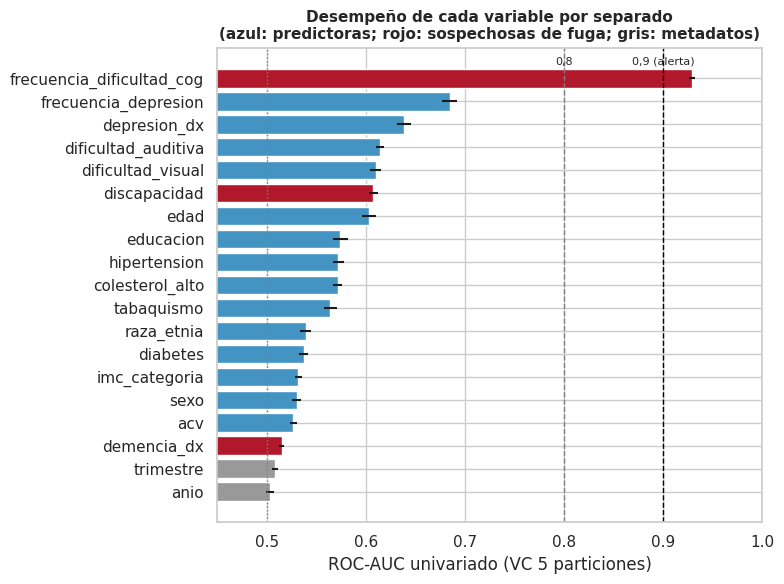

,AUC,de,grupo
frecuencia_dificultad_cog,0.929,0.003,Sospechosa
frecuencia_depresion,0.684,0.008,Predictora
depresion_dx,0.639,0.007,Predictora
dificultad_auditiva,0.614,0.004,Predictora
dificultad_visual,0.610,0.006,Predictora
discapacidad,0.608,0.005,Sospechosa
edad,0.603,0.007,Predictora
educacion,0.574,0.007,Predictora
hipertension,0.572,0.005,Predictora
colesterol_alto,0.571,0.005,Predictora


In [3]:
def auc_univariado(col):
    X = train[[col]].copy()
    if col == "edad":
        pre = Pipeline([("imp", SimpleImputer(strategy="median")), ("sp", SplineTransformer(n_knots=4)), ("esc", StandardScaler())])
    else:
        X[col] = X[col].map(str).replace({"nan": "Faltante"})
        pre = OneHotEncoder(handle_unknown="ignore")
    modelo = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=2000))])
    s = cross_val_score(modelo, X, y, cv=cv, scoring="roc_auc")
    return s.mean(), s.std()

candidatas = PREDICTORAS + SOSPECHOSAS + ["anio", "trimestre"]
res = {c: auc_univariado(c) for c in candidatas}
auc_uni = pd.DataFrame(res, index=["AUC", "de"]).T.sort_values("AUC")
auc_uni["grupo"] = ["Sospechosa" if c in SOSPECHOSAS else ("Metadato" if c in ["anio", "trimestre"] else "Predictora")
                    for c in auc_uni.index]

fig, ax = plt.subplots(figsize=(8, 6))
colores = auc_uni["grupo"].map({"Predictora": "#4393c3", "Sospechosa": "#b2182b", "Metadato": "#999999"})
ax.barh(auc_uni.index, auc_uni["AUC"], xerr=auc_uni["de"], color=colores)
for lim, txt in [(0.8, "0,8"), (0.9, "0,9 (alerta)")]:
    ax.axvline(lim, ls="--", color="black" if lim == 0.9 else "gray", lw=1)
    ax.text(lim, len(auc_uni) - 0.4, txt, ha="center", fontsize=8)
ax.axvline(0.5, ls=":", color="gray", lw=1)
ax.set_xlim(0.45, 1.0); ax.set_xlabel("ROC-AUC univariado (VC 5 particiones)")
ax.set_title("Desempeño de cada variable por separado\n(azul: predictoras; rojo: sospechosas de fuga; gris: metadatos)")
plt.tight_layout(); plt.show()
display(auc_uni.sort_values("AUC", ascending=False).style.format({"AUC": "{:.3f}", "de": "{:.3f}"}))

La auditoría cuantitativa confirma la sospecha conceptual sobre `frecuencia_dificultad_cog`: por sí
sola alcanza un AUC de 0,929, algo imposible para un factor de riesgo legítimo. No es que prediga el
objetivo, sino que lo contiene: su categoría de no aplica equivale a responder que no a la pregunta
objetivo. Si se hubiera incluido, el modelo habría superado artificialmente el umbral de 0,90 que la
guía señala como alerta, y el resultado habría sido pura fuga.

Las demás variables están lejos de ese umbral: las 14 predictoras tienen AUC univariados entre 0,527
para el ACV y 0,684 para la frecuencia de síntomas depresivos, un rango esperable para factores de
riesgo de un fenómeno multifactorial. El ACV tiene el AUC univariado más bajo a pesar de su OR alto,
porque solo afecta al 3,5 % de la muestra: identifica bien a los pocos casos que tiene, pero no
discrimina en la mayoría.

Hay dos resultados que muestran por qué esta auditoría no puede hacerse solo con números. La
variable `discapacidad` tiene un AUC de apenas 0,608, que por sí solo no dispararía ninguna alarma,
pero se construye con la misma pregunta objetivo, ya que quien responde mucha dificultad o no puede
en cognición queda clasificado automáticamente con discapacidad, así que es fuga por construcción.
La variable `demencia_dx` tiene un AUC de 0,515 porque la demencia es rara (0,8 %), pero
conceptualmente sigue siendo un proxy del objetivo.

Los metadatos de año y trimestre tienen un AUC cercano a 0,50, es decir que no contienen
información del objetivo, lo que confirma de nuevo la ausencia de deriva temporal.


### 2.5.3 Duplicados y entidades repetidas entre entrenamiento y prueba

In [4]:
clave_tr = set(zip(train["anio"], train["id_hogar"]))
clave_te = set(zip(test["anio"], test["id_hogar"]))
print(f"Adultos (año + hogar) presentes en ambos conjuntos: {len(clave_tr & clave_te)}")

perf = lambda df: df[PREDICTORAS].apply(lambda s: s.map(str)).agg("|".join, axis=1)
p_tr, p_te = perf(train), perf(test)
en_train = p_te.isin(set(p_tr))
print(f"Filas de prueba cuyo perfil de predictoras también aparece en entrenamiento: {en_train.sum():,} ({en_train.mean():.2%})")

# ¿Esos perfiles compartidos 'regalan' la etiqueta? Se compara la etiqueta de prueba con la
# prevalencia de ese mismo perfil en entrenamiento.
prev_perfil = train.assign(p=p_tr).groupby("p")[OBJETIVO].mean()
comp = test.loc[en_train, [OBJETIVO]].assign(prev_train=p_te[en_train].map(prev_perfil).values)
acierto_memoria = ((comp["prev_train"] >= 0.5).astype(int) == comp[OBJETIVO]).mean()
print(f"Acierto de 'memorizar' la etiqueta mayoritaria del perfil en entrenamiento: {acierto_memoria:.2%} "
      f"(vs. {1 - comp[OBJETIVO].mean():.2%} de predecir siempre la clase 0 en ese subconjunto)")
print(f"Prevalencia en filas de prueba con perfil compartido: {comp[OBJETIVO].mean():.2%}; "
      f"con perfil nuevo: {test.loc[~en_train, OBJETIVO].mean():.2%}")

Adultos (año + hogar) presentes en ambos conjuntos: 0


Filas de prueba cuyo perfil de predictoras también aparece en entrenamiento: 2,917 (25.98%)
Acierto de 'memorizar' la etiqueta mayoritaria del perfil en entrenamiento: 86.60% (vs. 91.64% de predecir siempre la clase 0 en ese subconjunto)
Prevalencia en filas de prueba con perfil compartido: 8.36%; con perfil nuevo: 24.90%


No hay entidades repetidas entre entrenamiento y prueba: ningún adulto, entendido como la
combinación de año y hogar, aparece en ambos conjuntos, y como hay un solo adulto por hogar no
existe riesgo de que información de una misma persona o familia cruce la partición.

Sí hay perfiles compartidos: el 26,0 % de las filas de prueba tiene exactamente la misma
combinación de predictoras que alguna fila de entrenamiento. Con 13 variables categóricas esto es
inevitable y no constituye fuga, por dos razones que el código verifica. La primera es que son
personas distintas: los perfiles compartidos son los más comunes, es decir los de adultos sanos, y
su prevalencia de dificultad cognitiva es de solo 8,4 %, frente a 24,9 % en los perfiles nuevos. La
segunda es que memorizar la etiqueta mayoritaria de cada perfil en entrenamiento acierta el 86,6 %
de las veces en esas filas, menos que predecir siempre la clase 0 (91,6 %). Un perfil repetido no
regala la respuesta.


### 2.5.4 Resultado de la auditoría

In [5]:
resultado = pd.DataFrame([
    ("frecuencia_dificultad_cog", "Descartada", f"AUC univariado = {auc_uni.loc['frecuencia_dificultad_cog', 'AUC']:.3f}; contiene el objetivo (faltante estructural)."),
    ("discapacidad", "Descartada", f"AUC univariado = {auc_uni.loc['discapacidad', 'AUC']:.3f}; se construye con la pregunta objetivo."),
    ("demencia_dx", "Descartada", "Proxy clínico del objetivo (demencia = deterioro cognitivo), aunque su AUC es bajo por ser rara."),
    ("id_hogar, anio, trimestre, peso_muestral", "Descartadas como predictoras", "Identificador y metadatos sin valor explicativo."),
    ("frecuencia_depresion", "En observación", "Mayor AUC entre predictoras, pero muy por debajo del umbral de alerta y conceptualmente distinta."),
    ("dificultad_auditiva, dificultad_visual", "En observación", "Mismo formato de respuesta que el objetivo (Washington Group): posible sesgo de estilo de respuesta."),
    ("Las 10 predictoras restantes", "Conservadas",
     "Disponibles al predecir y con AUC univariado entre {:.3f} y {:.3f}.".format(
         *auc_uni.loc[[c for c in PREDICTORAS if c not in ["frecuencia_depresion", "dificultad_auditiva", "dificultad_visual"]], "AUC"].agg(["min", "max"]))),
], columns=["variable(s)", "estado", "justificación"])
display(resultado.style.hide(axis="index").set_properties(**{"text-align": "left"}))

variable(s),estado,justificación
frecuencia_dificultad_cog,Descartada,AUC univariado = 0.929; contiene el objetivo (faltante estructural).
discapacidad,Descartada,AUC univariado = 0.608; se construye con la pregunta objetivo.
demencia_dx,Descartada,"Proxy clínico del objetivo (demencia = deterioro cognitivo), aunque su AUC es bajo por ser rara."
"id_hogar, anio, trimestre, peso_muestral",Descartadas como predictoras,Identificador y metadatos sin valor explicativo.
frecuencia_depresion,En observación,"Mayor AUC entre predictoras, pero muy por debajo del umbral de alerta y conceptualmente distinta."
"dificultad_auditiva, dificultad_visual",En observación,Mismo formato de respuesta que el objetivo (Washington Group): posible sesgo de estilo de respuesta.
Las 10 predictoras restantes,Conservadas,Disponibles al predecir y con AUC univariado entre 0.527 y 0.639.


El conjunto final de predictoras queda en 14 variables, todas disponibles al momento de predecir.
Se descartan tres variables por fuga, una detectada de forma numérica y conceptual, y dos solo de
forma conceptual, además de los identificadores y los metadatos.

Quedan en observación tres predictoras legítimas pero con un riesgo menor que conviene vigilar. La
frecuencia de síntomas depresivos, porque es la más potente de todas: la depresión puede alterar la
concentración y la percepción de la propia memoria, así que parte de su efecto puede ser
superposición de síntomas y no un factor de riesgo en sentido estricto. Y las dificultades auditiva
y visual, porque se preguntan con la misma escala del Washington Group que el objetivo, lo que
puede generar correlación por estilo de respuesta, es decir personas que tienden a reportar más
dificultades en general.

En las siguientes entregas se puede cuantificar ese riesgo comparando el desempeño del modelo con y
sin estas variables, mediante un análisis de sensibilidad.


## 2.9 Preprocesamiento

Todo el preprocesamiento está implementado en un `Pipeline` de scikit-learn
(`src/preprocesamiento.py`) que se ajusta solo con el conjunto de entrenamiento. Dentro de la
validación cruzada del modelo se reajusta en cada partición, de modo que ninguna estadística de
validación o de prueba se filtra al entrenamiento. Cada decisión de preprocesamiento se puede
rastrear hasta un hallazgo concreto del EDA:


In [6]:
decisiones = pd.DataFrame([
    ("Códigos 7/8/9 (se negó, no determinado, no sabe) → faltante", "Codebook NHIS", "src/utils.py (antes de la partición; no aprende de los datos)"),
    ("Excluir entrevistas por proxy", "1.4: el objetivo es dificultad percibida por la propia persona", "src/utils.py"),
    ("Agrupar AIAN y 'Otro / múltiple' en una categoría", "2.2.2: categorías < 1 % con estimaciones inestables", "FunctionTransformer"),
    ("Agrupar 'No puede' con 'Mucha' en audición y visión", "2.2.2 y 2.3.3: < 0,2 % y prevalencia con IC muy amplio", "FunctionTransformer"),
    ("Imputar categóricas con la moda", "1.9.1–1.9.2: faltantes < 3 %, mecanismo MAR", "SimpleImputer(most_frequent)"),
    ("Indicador de faltante en frecuencia_depresion, tabaquismo e imc_categoria", "1.9.2: faltante asociado a año, sexo y objetivo (no MCAR)", "MissingIndicator"),
    ("Imputar edad con la mediana", "1.9.1: 0,24 % de faltantes", "SimpleImputer(median)"),
    ("Splines cúbicos para la edad (4 nudos)", "2.3.2: relación en U con la prevalencia", "SplineTransformer"),
    ("Escalar la base de splines", "Regularización L2 sensible a la escala", "StandardScaler"),
    ("One-hot con categoría de referencia para todas las categóricas (incl. ordinales)", "2.3.3: relaciones no lineales (U en IMC, 'No puede' fuera del gradiente)", "OneHotEncoder(drop='first')"),
    ("Referencias: 'No', 'Nunca', 'Ninguna', 'Normal', 'Blanco no hispano', 'Hombre', 'Menos que secundaria'", "Categorías más frecuentes o clínicamente neutras: odds ratios interpretables", "categorías explícitas"),
    ("Usar imc_categoria y no el IMC numérico", "1.9.2: faltante MNAR del IMC numérico (8,5 %) vs. 2,2 %", "selección de variables"),
    ("No eliminar ni recortar outliers", "1.9.4 y 2.4.2: valores plausibles y perfiles reales de alto riesgo", "—"),
    ("No reducir dimensionalidad", "2.4.1: varianza muy repartida, VIF < 5", "—"),
    ("Excluir variables con fuga", "2.5: AUC univariado ≈ 1 o construidas con el objetivo", "selección de variables"),
], columns=["decisión", "hallazgo que la motiva", "implementación"])
display(decisiones.style.hide(axis="index").set_properties(**{"text-align": "left"}))

decisión,hallazgo que la motiva,implementación
"Códigos 7/8/9 (se negó, no determinado, no sabe) → faltante",Codebook NHIS,src/utils.py (antes de la partición; no aprende de los datos)
Excluir entrevistas por proxy,1.4: el objetivo es dificultad percibida por la propia persona,src/utils.py
Agrupar AIAN y 'Otro / múltiple' en una categoría,2.2.2: categorías < 1 % con estimaciones inestables,FunctionTransformer
Agrupar 'No puede' con 'Mucha' en audición y visión,"2.2.2 y 2.3.3: < 0,2 % y prevalencia con IC muy amplio",FunctionTransformer
Imputar categóricas con la moda,"1.9.1–1.9.2: faltantes < 3 %, mecanismo MAR",SimpleImputer(most_frequent)
"Indicador de faltante en frecuencia_depresion, tabaquismo e imc_categoria","1.9.2: faltante asociado a año, sexo y objetivo (no MCAR)",MissingIndicator
Imputar edad con la mediana,"1.9.1: 0,24 % de faltantes",SimpleImputer(median)
Splines cúbicos para la edad (4 nudos),2.3.2: relación en U con la prevalencia,SplineTransformer
Escalar la base de splines,Regularización L2 sensible a la escala,StandardScaler
One-hot con categoría de referencia para todas las categóricas (incl. ordinales),"2.3.3: relaciones no lineales (U en IMC, 'No puede' fuera del gradiente)",OneHotEncoder(drop='first')


In [7]:
from src.preprocesamiento import construir_preprocesador

pre = construir_preprocesador()
X_tr = pre.fit_transform(train[PREDICTORAS])
nombres = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]
print(f"Matriz de entrenamiento transformada: {X_tr.shape[0]:,} filas x {X_tr.shape[1]} columnas")
print(f"Valores faltantes tras el preprocesamiento: {np.isnan(X_tr).sum()}")
print("\nColumnas generadas:")
for i in range(0, len(nombres), 3):
    print("   " + " | ".join(nombres[i:i + 3]))
display(pd.DataFrame(X_tr[:5], columns=nombres).round(2))

Matriz de entrenamiento transformada: 44,903 filas x 35 columnas
Valores faltantes tras el preprocesamiento: 0

Columnas generadas:
   edad_sp_0 | edad_sp_1 | edad_sp_2
   edad_sp_3 | edad_sp_4 | sexo_Mujer
   raza_etnia_Hispano | raza_etnia_Negro no hispano | raza_etnia_Asiático no hispano
   raza_etnia_Otro / múltiple (incl. AIAN) | educacion_Secundaria o GED | educacion_Técnico o universidad incompleta
   educacion_Pregrado | educacion_Posgrado | hipertension_Sí
   colesterol_alto_Sí | diabetes_Sí | acv_Sí
   depresion_dx_Sí | frecuencia_depresion_Pocas veces al año | frecuencia_depresion_Mensual
   frecuencia_depresion_Semanal | frecuencia_depresion_Diaria | dificultad_auditiva_Alguna
   dificultad_auditiva_Mucha o no puede | dificultad_visual_Alguna | dificultad_visual_Mucha o no puede
   tabaquismo_Exfumador | tabaquismo_Fumador actual | imc_categoria_Bajo peso
   imc_categoria_Sobrepeso | imc_categoria_Obesidad | missingindicator_frecuencia_depresion
   missingindicator_tabaquis

,edad_sp_0,edad_sp_1,edad_sp_2,edad_sp_3,edad_sp_4,sexo_Mujer,raza_etnia_Hispano,raza_etnia_Negro no hispano,raza_etnia_Asiático no hispano,raza_etnia_Otro / múltiple (incl. AIAN),educacion_Secundaria o GED,educacion_Técnico o universidad incompleta,educacion_Pregrado,educacion_Posgrado,hipertension_Sí,colesterol_alto_Sí,diabetes_Sí,acv_Sí,depresion_dx_Sí,frecuencia_depresion_Pocas veces al año,frecuencia_depresion_Mensual,frecuencia_depresion_Semanal,frecuencia_depresion_Diaria,dificultad_auditiva_Alguna,dificultad_auditiva_Mucha o no puede,dificultad_visual_Alguna,dificultad_visual_Mucha o no puede,tabaquismo_Exfumador,tabaquismo_Fumador actual,imc_categoria_Bajo peso,imc_categoria_Sobrepeso,imc_categoria_Obesidad,missingindicator_frecuencia_depresion,missingindicator_tabaquismo,missingindicator_imc_categoria
0,-0.3500,-0.4100,1.1400,0.0000,-0.7500,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
1,-0.3500,-0.6800,-1.0300,1.1200,0.6400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
2,-0.3500,-0.6500,0.2500,0.9200,-0.5500,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
3,-0.3500,-0.4100,1.1400,0.0000,-0.7500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
4,-0.3500,0.0400,1.4600,-0.6800,-0.7700,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000


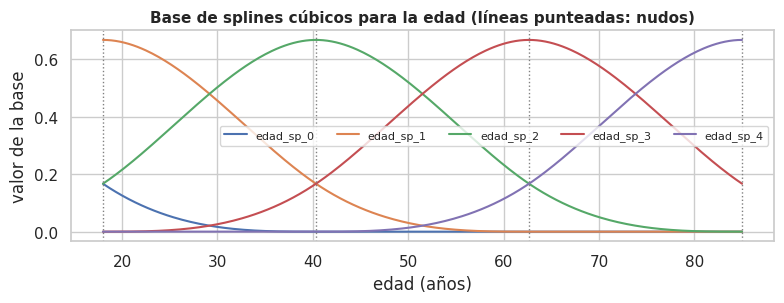

In [8]:
# Visualización de la base de splines aprendida para la edad (nudos ubicados en cuantiles del entrenamiento)
sp = pre.named_transformers_["num"].named_steps["spline"]
edades = np.linspace(18, 85, 300).reshape(-1, 1)
base = sp.transform(edades)
fig, ax = plt.subplots(figsize=(8, 3.2))
for j in range(base.shape[1]):
    ax.plot(edades, base[:, j], label=f"edad_sp_{j}")
for nudo in sp.bsplines_[0].t[3:-3]:
    ax.axvline(nudo, color="gray", ls=":", lw=1)
ax.set_xlabel("edad (años)"); ax.set_ylabel("valor de la base"); ax.legend(fontsize=8, ncol=5)
ax.set_title("Base de splines cúbicos para la edad (líneas punteadas: nudos)")
plt.tight_layout(); plt.show()

El pipeline transforma las 14 predictoras en 35 columnas sin ningún valor faltante: 5 columnas de
splines para la edad, 27 columnas one-hot, una por cada categoría distinta de la referencia, y 3
indicadores de faltante. La base de splines muestra cómo queda modelada la edad: en lugar de un
único coeficiente, como sería una recta, el modelo combina 5 curvas locales cuyos nudos se ubican en
los cuantiles de la edad del entrenamiento, lo que le permite reproducir la forma en U que se vio en
el EDA.

El preprocesamiento tiene tres garantías contra la fuga de información. La mediana, la moda, las
posiciones de los nudos y las medias y desviaciones del escalado se calculan solo con el
entrenamiento. Dentro de la validación cruzada, el pipeline completo se reajusta en cada partición.
Y el conjunto de prueba solo se transforma, nunca se ajusta, y eso ocurre al final, en la
evaluación.

Las categorías de referencia se eligieron para que cada odds ratio se lea de forma natural, por
ejemplo tener hipertensión frente a no tenerla, o sentirse deprimido a diario frente a nunca.
